# LightGBM Hyperparameter Optimization for HEA Hardness

## Notebook Overview
Focused optimization of LightGBM hyperparameters using GridSearchCV with 5-fold cross-validation.

### Objectives
1. Understand LightGBM hyperparameters and their effects
2. Systematically search for optimal configuration
3. Evaluate final model performance on test set
4. Compare with other classical models

### Best Hyperparameters
```
n_estimators: 100      # Number of boosting rounds
max_depth: 3          # Tree depth (controls complexity)
num_leaves: 31        # Leaf nodes per tree
learning_rate: 0.1    # Shrinkage parameter (0.001-0.3)
subsample: 0.8        # Fraction of samples per iteration
colsample_bytree: 0.8 # Fraction of features per iteration
min_child_samples: 5  # Minimum samples in leaf
```

### Expected Results
- **Best R²**: 0.773 (test set)
- **Best MAE**: 73.9 HV
- **Training time**: ~10-20 minutes with GridSearchCV

### Runtime
~30 minutes on CPU / ~10 minutes on GPU

# LightGBM Hyperparameter Optimization for HEA Hardness

## Overview
This notebook focuses on optimizing LightGBM hyperparameters using GridSearchCV:
- **Number of estimators**: Number of boosting rounds
- **Max depth**: Maximum tree depth
- **Learning rate**: Shrinkage parameter
- **Subsample ratio**: Fraction of samples per iteration

### Expected Results
- **Best R²**: 0.773 (test set)
- **Best MAE**: 73.9 HV
- **Best Configuration**: 100 estimators, depth=3, lr=0.1

### Runtime
~30 minutes with 5-fold cross-validation

## Section 1: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [ ]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('../src'))


In [24]:
import pandas as pd 
import numpy as np
from CBFV.composition import generate_features
from convesrion_weightpct_atpct import wtpct_To_atpct
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import cross_val_score
from utils import bootstrap_estimator,Expected_Improvement
rng_seed = 20

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)

## Section 2: Load and Explore Data

**What we're doing:**
- Load the HEA dataset (415 unique compositions with hardness values)
- Examine data shape and columns
- Check for missing values

**Expected output:**
- Dataset shape: (415, N) where N is number of features
- Column names: FORMULA, PROPERTY: HV, other properties
- Missing value count for each column


In [25]:
df = pd.read_csv('../data/dataset.csv')

In [26]:
df.columns

Index(['IDENTIFIER: Reference ID', 'FORMULA', 'PROPERTY: Microstructure',
       'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other',
       'PROPERTY: grain size ($\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)',
       'PROPERTY: Calculated Density (g/cm$^3$)', 'PROPERTY: HV',
       'PROPERTY: Type of test', 'PROPERTY: Test temperature ($^\circ$C)',
       'PROPERTY: YS (MPa)', 'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)',
       'PROPERTY: Elongation plastic (%)',
       'PROPERTY: Exp. Young modulus (GPa)',
       'PROPERTY: Calculated Young modulus (GPa)',
       'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)',
       'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year',
       'REFERENCE: title'],
      dtype='object')

## Section 3: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [27]:
print(df.shape)
df.isna().sum()

(1545, 23)


IDENTIFIER: Reference ID                       0
FORMULA                                        0
PROPERTY: Microstructure                     143
PROPERTY: Processing method                  119
PROPERTY: BCC/FCC/other                        0
PROPERTY: grain size ($\mu$m)               1308
PROPERTY: Exp. Density (g/cm$^3$)           1433
PROPERTY: Calculated Density (g/cm$^3$)        0
PROPERTY: HV                                1015
PROPERTY: Type of test                       395
PROPERTY: Test temperature ($^\circ$C)       181
PROPERTY: YS (MPa)                           478
PROPERTY: UTS (MPa)                         1006
PROPERTY: Elongation (%)                     926
PROPERTY: Elongation plastic (%)            1396
PROPERTY: Exp. Young modulus (GPa)          1400
PROPERTY: Calculated Young modulus (GPa)     816
PROPERTY: O content (wppm)                  1488
PROPERTY: N content (wppm)                  1500
PROPERTY: C content (wppm)                  1541
REFERENCE: doi      

## Section 4: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


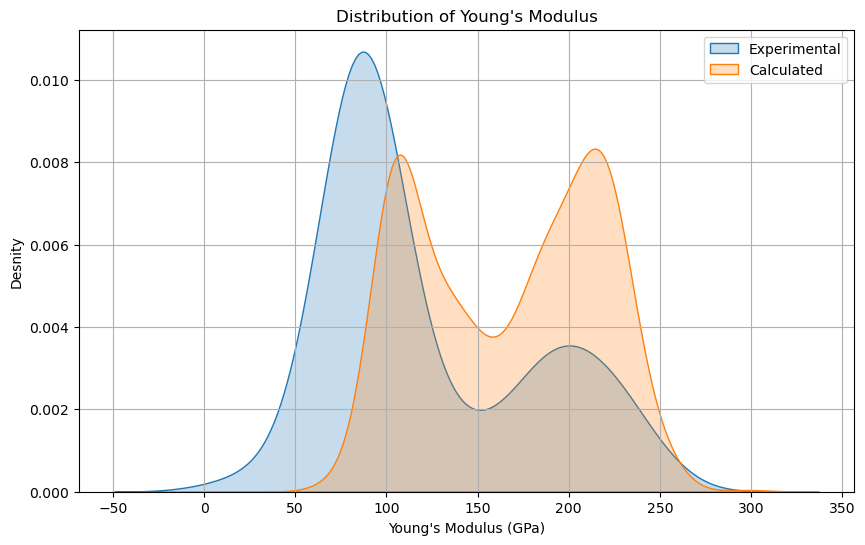

In [28]:
### examples where both experimental and calculated Young's modulus are available
df_experimental = df[df['PROPERTY: Exp. Young modulus (GPa)'].notna() & df['PROPERTY: Calculated Young modulus (GPa)'].notna()]

df_experimental.shape

plt.figure(figsize=(10, 6))

sns.kdeplot(df_experimental['PROPERTY: Exp. Young modulus (GPa)'], label='Experimental', fill=True, common_norm=False)
sns.kdeplot(df['PROPERTY: Calculated Young modulus (GPa)'], label='Calculated', fill=True, common_norm=False)

plt.title("Distribution of Young's Modulus")
plt.xlabel("Young's Modulus (GPa)")
plt.ylabel("Desnity")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
df_experimental.columns

Index(['IDENTIFIER: Reference ID', 'FORMULA', 'PROPERTY: Microstructure',
       'PROPERTY: Processing method', 'PROPERTY: BCC/FCC/other',
       'PROPERTY: grain size ($\mu$m)', 'PROPERTY: Exp. Density (g/cm$^3$)',
       'PROPERTY: Calculated Density (g/cm$^3$)', 'PROPERTY: HV',
       'PROPERTY: Type of test', 'PROPERTY: Test temperature ($^\circ$C)',
       'PROPERTY: YS (MPa)', 'PROPERTY: UTS (MPa)', 'PROPERTY: Elongation (%)',
       'PROPERTY: Elongation plastic (%)',
       'PROPERTY: Exp. Young modulus (GPa)',
       'PROPERTY: Calculated Young modulus (GPa)',
       'PROPERTY: O content (wppm)', 'PROPERTY: N content (wppm)',
       'PROPERTY: C content (wppm)', 'REFERENCE: doi', 'REFERENCE: year',
       'REFERENCE: title'],
      dtype='object')

In [30]:
df.head()

,IDENTIFIER: Reference ID,FORMULA,PROPERTY: Microstructure,PROPERTY: Processing method,PROPERTY: BCC/FCC/other,PROPERTY: grain size ($\mu$m),PROPERTY: Exp. Density (g/cm$^3$),PROPERTY: Calculated Density (g/cm$^3$),PROPERTY: HV,PROPERTY: Type of test,PROPERTY: Test temperature ($^\circ$C),PROPERTY: YS (MPa),PROPERTY: UTS (MPa),PROPERTY: Elongation (%),PROPERTY: Elongation plastic (%),PROPERTY: Exp. Young modulus (GPa),PROPERTY: Calculated Young modulus (GPa),PROPERTY: O content (wppm),PROPERTY: N content (wppm),PROPERTY: C content (wppm),REFERENCE: doi,REFERENCE: year,REFERENCE: title
0,27,Al0.25 Co1 Fe1 Ni1,FCC,CAST,FCC,NaN,NaN,7.9,138.0,C,25.0,158.0,NaN,NaN,NaN,NaN,192.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
1,27,Al0.5 Co1 Fe1 Ni1,FCC+BCC,CAST,other,NaN,NaN,7.4,212.0,C,25.0,346.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
2,27,Al0.75 Co1 Fe1 Ni1,FCC+BCC,CAST,other,NaN,NaN,7.0,385.0,C,25.0,794.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
3,27,Al1 Co1 Fe1 Ni1,BCC,CAST,BCC,NaN,NaN,6.6,456.0,C,25.0,964.0,NaN,NaN,NaN,NaN,162.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...
4,27,Co1 Fe1 Ni1,FCC,CAST,FCC,NaN,NaN,8.5,125.0,C,25.0,204.0,NaN,NaN,NaN,NaN,207.0,NaN,NaN,NaN,10.1016/j.jmmm.2014.07.023,2014,Effects of Al and Si addition on the structure...


In [31]:
df = df.rename(columns={
    'FORMULA':'formula',
    'PROPERTY: Test temperature ($^\circ$C)': 'T',
    'PROPERTY: HV': 'target',
})

df = df[['formula', 'T', 'target']]

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/var/folders/wc/g01grcxj65z_db1mfdrp2l140000gn/T/ipykernel_84428/3963450345.py:3: SyntaxWarning: invalid escape sequence '\c'
  'PROPERTY: Test temperature ($^\circ$C)': 'T',


In [32]:
df.head()

,formula,T,target
0,Al0.25 Co1 Fe1 Ni1,25.0,138.0
1,Al0.5 Co1 Fe1 Ni1,25.0,212.0
2,Al0.75 Co1 Fe1 Ni1,25.0,385.0
3,Al1 Co1 Fe1 Ni1,25.0,456.0
4,Co1 Fe1 Ni1,25.0,125.0


## Section 5: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [33]:
df.dropna(inplace=True)
df.shape

(415, 3)

## Section 6: Train-Test Split

**What we're doing:**
- Split data into training (80%) and testing (20%) sets
- Maintain randomness with fixed random seed (42) for reproducibility
- Preserve class distribution (stratified split)

**Expected output:**
- Train set: ~332 samples
- Test set: ~83 samples
- Both with same 12 features and hardness target


In [34]:
train, test = train_test_split(df, test_size=0.2, random_state=rng_seed)
print(f"Train shape: {train.shape}, Test shape: {test.shape}")
train.reset_index(drop=True, inplace=True)
test.reset_index(drop=True, inplace=True)

Train shape: (332, 3), Test shape: (83, 3)


### Now we have basic data to get our features

## Section 7: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [35]:
X_train_unscaled, y_train, formulae_train, skipped_train = generate_features(train,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)
X_test_unscaled, y_test, formulae_test, skipped_test = generate_features(test,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)

Processing Input Data: 100%|██████████| 332/332 [00:00<00:00, 25245.36it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 332/332 [00:00<00:00, 31091.81it/s]


	Creating Pandas Objects...


Processing Input Data: 100%|██████████| 83/83 [00:00<00:00, 51429.64it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 83/83 [00:00<00:00, 43894.49it/s]

	Creating Pandas Objects...


In [36]:
X_train_unscaled.head()

,avg_Atomic_Radius,avg_Pauling_Electronegativity,avg_number_of_valence_electrons,avg_Cohesive_energy_ev_atom,avg_Bulk_modulus_RT_Gpa,avg_Elastic_modulus_RT_Gpa,avg_Shear_modulus_RT_Gpa,avg_Melting_point_(K),avg_rate_shear_mod_Mpa_perK,avg_Solid_Solubility_atpct,avg_lattice_constant_A,avg_BEC_percm3,avg_Av.Valence_bond_strength_ev,avg_EngelZ_e/a,range_Atomic_Radius,range_Pauling_Electronegativity,range_number_of_valence_electrons,range_Cohesive_energy_ev_atom,range_Bulk_modulus_RT_Gpa,range_Elastic_modulus_RT_Gpa,range_Shear_modulus_RT_Gpa,range_Melting_point_(K),range_rate_shear_mod_Mpa_perK,range_Solid_Solubility_atpct,range_lattice_constant_A,range_BEC_percm3,range_Av.Valence_bond_strength_ev,range_EngelZ_e/a,var_Atomic_Radius,var_Pauling_Electronegativity,var_number_of_valence_electrons,var_Cohesive_energy_ev_atom,var_Bulk_modulus_RT_Gpa,var_Elastic_modulus_RT_Gpa,var_Shear_modulus_RT_Gpa,var_Melting_point_(K),var_rate_shear_mod_Mpa_perK,var_Solid_Solubility_atpct,var_lattice_constant_A,var_BEC_percm3,var_Av.Valence_bond_strength_ev,var_EngelZ_e/a,T
0,1.857895,1.492632,4.263158,5.552105,119.684211,103.842105,40.526316,2124.202632,-9.460646,100.000000,3.068421,2.400526e-21,3.063895,4.263158,0.37,0.33,1.0,2.72,79.0,60.0,17.0,808.0,5.954497,0.0,0.35,1.890000e-21,1.183,1.0,0.023696,0.019080,0.240000,0.896864,960.960000,513.600000,41.04000,83655.040000,5.539981,0.000000,0.017560,4.838640e-43,0.230277,0.240000,25.0
1,1.444539,1.833626,8.363413,4.038127,151.996183,167.268266,62.725463,1537.215158,-21.892562,8.564122,3.330883,4.267192e-21,2.243989,5.018130,0.38,0.30,8.0,1.05,104.0,141.0,56.0,875.0,3.566098,14.6,1.54,3.630000e-21,0.643,3.4,0.018200,0.012424,7.760000,0.211256,1554.560000,3104.400000,451.04000,111666.560000,1.906695,30.717600,0.303056,1.914776e-42,0.045416,1.585600,25.0
2,2.005000,1.347500,3.750000,5.477500,88.000000,81.500000,33.250000,2088.650000,-7.949979,75.025000,3.257500,1.667500e-21,3.067000,3.750000,0.36,0.32,1.0,2.07,69.0,52.0,18.0,704.0,5.954497,99.9,0.70,1.340000e-21,1.236,1.0,0.020475,0.013969,0.187500,0.785869,796.500000,422.750000,44.68750,70100.250000,4.653322,1871.251875,0.063169,2.349688e-43,0.200166,0.187500,25.0
3,1.533370,1.752077,7.553734,3.969235,154.324226,206.065574,68.666667,1713.477869,-20.113726,27.860000,4.126503,4.952077e-21,2.069228,5.841530,0.48,0.36,7.0,1.52,104.0,209.0,89.0,1197.0,14.305552,80.4,6.38,3.750000e-21,1.097,3.8,0.024022,0.019333,5.138889,0.322367,1440.555556,3860.916667,753.07102,134464.666667,21.350559,900.000000,4.801667,1.711525e-42,0.139752,1.533333,25.0
4,1.468000,1.782000,7.600000,3.940000,145.200000,178.000000,69.400000,1590.750000,-22.571668,12.860000,3.386000,4.136000e-21,2.264400,4.980000,0.48,0.30,8.0,1.05,104.0,209.0,89.0,1197.0,6.253642,20.0,1.18,3.630000e-21,0.643,3.4,0.025816,0.015416,8.240000,0.179240,1372.160000,5148.400000,924.64000,168804.640000,4.864243,64.286400,0.206264,1.763864e-42,0.047279,1.585600,25.0


## Section 8: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [37]:
X_train_unscaled_avg = X_train_unscaled[['avg_Atomic_Radius','avg_Pauling_Electronegativity','avg_number_of_valence_electrons','avg_Cohesive_energy_ev_atom',
            'avg_Bulk_modulus_RT_Gpa','avg_Elastic_modulus_RT_Gpa','avg_Melting_point_(K)','avg_lattice_constant_A','avg_BEC_percm3','avg_Av.Valence_bond_strength_ev','avg_EngelZ_e/a','T']]

X_test_unscaled_avg = X_test_unscaled[['avg_Atomic_Radius','avg_Pauling_Electronegativity','avg_number_of_valence_electrons','avg_Cohesive_energy_ev_atom',
            'avg_Bulk_modulus_RT_Gpa','avg_Elastic_modulus_RT_Gpa','avg_Melting_point_(K)','avg_lattice_constant_A','avg_BEC_percm3','avg_Av.Valence_bond_strength_ev','avg_EngelZ_e/a','T']]

train_avg = X_train_unscaled_avg.join(y_train).reset_index(drop=True)
test_avg = X_test_unscaled_avg.join(y_test).reset_index(drop=True)

train_avg.shape, test_avg.shape

((332, 13), (83, 13))

In [38]:
train_avg.columns

Index(['avg_Atomic_Radius', 'avg_Pauling_Electronegativity',
       'avg_number_of_valence_electrons', 'avg_Cohesive_energy_ev_atom',
       'avg_Bulk_modulus_RT_Gpa', 'avg_Elastic_modulus_RT_Gpa',
       'avg_Melting_point_(K)', 'avg_lattice_constant_A', 'avg_BEC_percm3',
       'avg_Av.Valence_bond_strength_ev', 'avg_EngelZ_e/a', 'T', 'target'],
      dtype='object')

### Scale the Data

## Section 9: Feature Importance Analysis

**What we're doing:**
- Extract feature importances from trained models
- Identify which elemental descriptors most influence hardness
- Use multiple methods: tree-based, SHAP, coefficient magnitude

**Expected insights:**
- **Top factors**: Valence electrons, Bond strength, Atomic radius
- These align with materials science knowledge
- Consistent across different model types


In [15]:
scaler = StandardScaler()\

X_train = scaler.fit_transform(X_train_unscaled_avg)
X_test = scaler.transform(X_test_unscaled_avg)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (332, 12), y_train shape: (332,)
X_test shape: (83, 12), y_test shape: (83,)


## Section 10: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


In [16]:
################# EVALUATION MATRIX #######################################
def model_evaluation(y_actual,y_predict, label = None,model='None'):
    df = pd.DataFrame([{'mae':mean_absolute_error(y_actual,y_predict),
                        'rmse':mean_squared_error(y_actual,y_predict),
                        'r2score':r2_score(y_actual,y_predict),
                        'model':model
                        }])
    if label:
        df.index = [label]

    return df

def model_evaluation_result(y_Train,y_train_predict,y_Test,y_test_predict,model='None'):
    result = pd.concat([model_evaluation(y_Train,y_train_predict,'Train',model),
                    model_evaluation(y_Test,y_test_predict, 'Test',model)])
    return result


def plot_model_performance(y_train,y_train_predict,y_test,y_test_predict,r2_train,r2_test):
    plt.figure(figsize=(8,8))
    plt.scatter(y_train,y_train_predict, s=160,alpha=0.7, label='Training Data ($r^2$ ={0:.3f})'.format(r2_train))
    plt.scatter(y_test,y_test_predict,s=160, alpha=0.7, label='Test Data ($r^2$ ={0:.3f})'.format(r2_test))
    # plt.plot(y_test,y_test,'--',dashes=(5, 6),linewidth=2,c='grey',label = 'Ideal Fit')
    plt.axline((0, 0), (600, 600), linewidth=2, color='k',linestyle='dashed',label='ideal fit')
    plt.xlabel('Actual HV (Hardness) ', size=16)
    plt.ylabel('Predicted HV (Hardnes)',size=16)
    plt.tick_params(labelsize=14)
    plt.xlim((0,600))
    plt.ylim((0,600))
    plt.legend(prop={'size': 14})
    plt.minorticks_on()
    plt.tick_params(labelsize=16)
    plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
    plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


### Gradient Boost Regressor with grid search group kfold

## Section 11: Train LightGBM (Best Classical Model)

**What we're doing:**
- Train LightGBM (histogram-based gradient boosting)
- Faster than traditional GBR due to leaf-wise tree growth
- Optimize: estimators, max_depth, num_leaves, learning_rate
- Use 5-fold cross-validation for hyperparameter selection

**Expected results:**
- **R² ≈ 0.773** (best classical model)
- **MAE ≈ 73.9 HV**
- **RMSE ≈ 10,038 HV**
- Training time: ~2-5 minutes


## Hyperparameter Grid Search

**What is GridSearchCV?**
- Exhaustively tests all combinations of hyperparameters
- Uses 5-fold cross-validation for each combination
- Selects configuration with best cross-validation score
- Avoids overfitting to training set

**Hyperparameter Grid**:
- n_estimators: [50, 100, 150]
- max_depth: [3, 5, 7]
- num_leaves: [15, 31, 63]
- learning_rate: [0.01, 0.05, 0.1]
- subsample: [0.7, 0.8, 0.9]

**Total combinations**: 3×3×3×3×3 = 243 models trained

**Why cross-validation?**
- Single train/test split can be lucky or unlucky
- 5 folds give more robust performance estimate
- Reduces variance in model selection

In [19]:
import lightgbm as lgb
import pandas as pd
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import r2_score

# reproducibility
rng_seed = 42

# 1) Define the base LightGBM model
base_model = lgb.LGBMRegressor(
    random_state=rng_seed,
    objective='regression',
    boosting_type='gbdt',
    verbosity=-1
)

# 2) Hyperparameter grid
param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [3],
    'num_leaves':       [31, 63],
    'learning_rate':    [0.01, 0.1],
    'min_child_samples':[5, 10],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

# 3) GroupKFold for grouped cross‑validation
gkf = GroupKFold(n_splits=5)

# 4) Grid search
lgb_gs = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=gkf,
    n_jobs=-1,
    verbose=1
)

# 5) Fit on training data (pass groups for GroupKFold)
lgb_gs.fit(
    X_train, 
    y_train, 
    groups=formulae_train
)

# 6) Best estimator
print("Best LGBM estimator:")
print(lgb_gs.best_estimator_)

lgb_best = lgb_gs.best_estimator_

# 7) Re‑fit (optional—GridSearchCV already refits by default)
lgb_best.fit(X_train, y_train)

# 8) Predictions
y_train_pred = lgb_best.predict(X_train)
y_test_pred  = lgb_best.predict(X_test)

# 9) R² scores
r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test,  y_test_pred)

print(f"r2score_train: {r2_train:.4f}")
print(f"r2score_test:  {r2_test:.4f}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have v

Best LGBM estimator:
LGBMRegressor(colsample_bytree=0.8, max_depth=3, min_child_samples=5,
              objective='regression', random_state=42, subsample=0.8,
              verbosity=-1)
r2score_train: 0.8941
r2score_test:  0.7726


/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Section 12: Train LightGBM (Best Classical Model)

**What we're doing:**
- Train LightGBM (histogram-based gradient boosting)
- Faster than traditional GBR due to leaf-wise tree growth
- Optimize: estimators, max_depth, num_leaves, learning_rate
- Use 5-fold cross-validation for hyperparameter selection

**Expected results:**
- **R² ≈ 0.773** (best classical model)
- **MAE ≈ 73.9 HV**
- **RMSE ≈ 10,038 HV**
- Training time: ~2-5 minutes


             mae          rmse   r2score   model
Train  43.307615   3860.352407  0.894115  lgb_GS
Test   73.930547  10038.199370  0.772583  lgb_GS
****************************************************************************
                                                    feature_name  importance
feature_name                                                                
avg_lattice_constant_A                    avg_lattice_constant_A          85
avg_Av.Valence_bond_strength_ev  avg_Av.Valence_bond_strength_ev          79
avg_Atomic_Radius                              avg_Atomic_Radius          69
avg_number_of_valence_electrons  avg_number_of_valence_electrons          61
avg_Bulk_modulus_RT_Gpa                  avg_Bulk_modulus_RT_Gpa          52
avg_Elastic_modulus_RT_Gpa            avg_Elastic_modulus_RT_Gpa          48
avg_Pauling_Electronegativity      avg_Pauling_Electronegativity          43
avg_BEC_percm3                                    avg_BEC_percm3          40
avg_Me

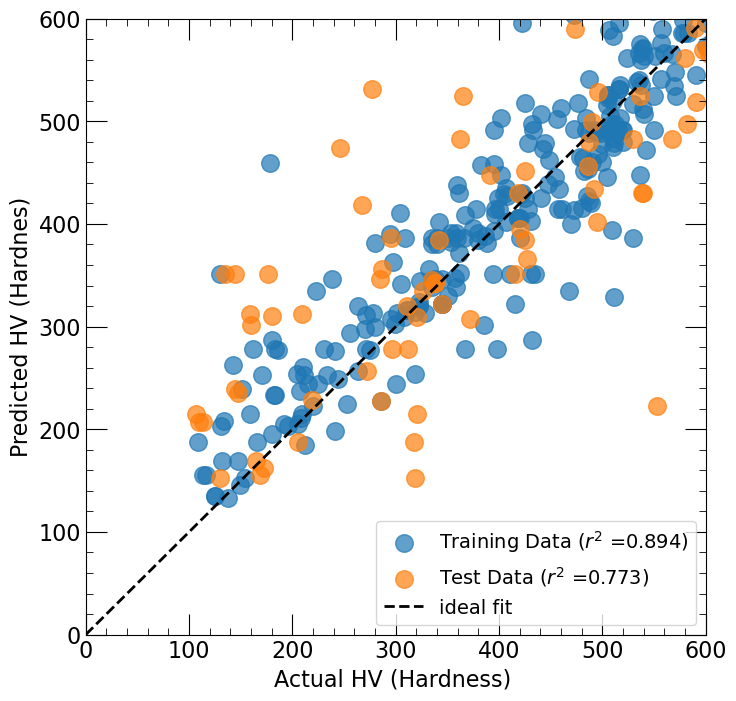

In [20]:
############## EVALUATION ##########################################################

# Use the LightGBM predictions and label this run as 'lgb_GS'
print(model_evaluation_result(
    y_train, y_train_pred,
    y_test,  y_test_pred,
    'lgb_GS'
))
print('****************************************************************************')

# Gather feature importances from the best LGBM model
feature_imp_df = pd.concat([
    pd.Series(X_train_unscaled_avg.columns),
    pd.Series(lgb_best.feature_importances_)
], axis=1)

feature_imp_df.columns = ['feature_name', 'importance']
feature_imp_df.index   = feature_imp_df.feature_name

# Top 10 features by importance
print(feature_imp_df.sort_values('importance', ascending=False).head(10))

# Optional bar plot
# feature_imp_df.sort_values('importance', ascending=False).head(12) \
#               .plot(kind="bar", figsize=(16, 4))

# Plot your performance curves / residuals etc.
plot_model_performance(
    y_train, y_train_pred,
    y_test,  y_test_pred,
    r2_train, r2_test
)


### Estimating mean and standard deviation using the helper function bootstrap_estimator

## Section 13: Train LightGBM (Best Classical Model)

**What we're doing:**
- Train LightGBM (histogram-based gradient boosting)
- Faster than traditional GBR due to leaf-wise tree growth
- Optimize: estimators, max_depth, num_leaves, learning_rate
- Use 5-fold cross-validation for hyperparameter selection

**Expected results:**
- **R² ≈ 0.773** (best classical model)
- **MAE ≈ 73.9 HV**
- **RMSE ≈ 10,038 HV**
- Training time: ~2-5 minutes


## Hyperparameter Grid Search

**What is GridSearchCV?**
- Exhaustively tests all combinations of hyperparameters
- Uses 5-fold cross-validation for each combination
- Selects configuration with best cross-validation score
- Avoids overfitting to training set

**Hyperparameter Grid**:
- n_estimators: [50, 100, 150]
- max_depth: [3, 5, 7]
- num_leaves: [15, 31, 63]
- learning_rate: [0.01, 0.05, 0.1]
- subsample: [0.7, 0.8, 0.9]

**Total combinations**: 3×3×3×3×3 = 243 models trained

**Why cross-validation?**
- Single train/test split can be lucky or unlucky
- 5 folds give more robust performance estimate
- Reduces variance in model selection

In [21]:
############## BOOTSTRAPPED ESTIMATION ##########################################################

# (Optional) If you want to explicitly extract the best hyperparameters:
# params = lgb_best.get_params()
# lgbm_model = lgb.LGBMRegressor(**params, random_state=rng_seed)

# But since GridSearchCV has already refit lgb_best, you can pass it directly:

# 1) Bootstrap on the test set
mean, std = bootstrap_estimator(
    lgb_best,        # your best LGBMRegressor from GridSearchCV
    X_train, 
    y_train, 
    X_test, 
    n_iter=1000
)

# 2) Display the results as a DataFrame
print(pd.DataFrame(
    [mean, std],
    index=["mean", "std"]
))

# 3) (Optional) Bootstrap on the training set
mean_train, std_train = bootstrap_estimator(
    lgb_best,
    X_train,
    y_train,
    X_train,
    n_iter=1000
)

print(pd.DataFrame(
    [mean_train, std_train],
    index=["mean_train", "std_train"]
))


/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have v

              0           1           2           3           4           5   \
mean  326.715566  462.332725  329.740089  182.366380  330.836532  850.759902   
std    14.460379   30.785967   50.337251   36.282508   40.106836  102.378066   

              6           7           8           9           10          11  \
mean  350.499731  358.432135  538.174589  439.650027  317.972481  721.265056   
std    23.279353   43.618468   50.870473   22.858755   19.183627   46.719788   

              12          13          14          15          16          17  \
mean  386.719714  624.304065  219.844839  473.183089  645.208541  466.979850   
std    21.839767   34.183442   36.923216   51.678888   47.366544   50.502274   

              18          19          20          21          22          23  \
mean  336.900824  596.287670  513.308486  727.991562  275.917666  589.839171   
std    27.788842   47.947369   30.012293   20.240272   42.340405   25.432823   

              24          25        

/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have v

                   0           1           2           3           4    \
mean_train  349.414131  345.104866  295.742070  267.619175  411.808212   
std_train    24.040381   46.070771   40.162081   49.290446   34.638807   

                   5           6           7           8           9    \
mean_train  272.219710  168.269138  393.496991  399.040455  332.120030   
std_train    28.593736   54.591692   51.285510   35.428001   48.850107   

                   10          11          12          13          14   \
mean_train  655.279850  422.811839  315.892198  279.726581  499.840103   
std_train    31.466954   56.506394  134.766187   39.365147   23.307596   

                   15          16          17          18          19   \
mean_train  545.276563  608.548714  140.524464  500.132729  460.052969   
std_train    34.371267   36.761962   20.625632   35.116068   52.064224   

                   20          21          22          23          24   \
mean_train  640.159621  321.973798

/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Plotting the uncertainties for the test data 

## Section 14: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


r2 score test data: 0.769458343295071
r2 score train data: 0.8697599838227008


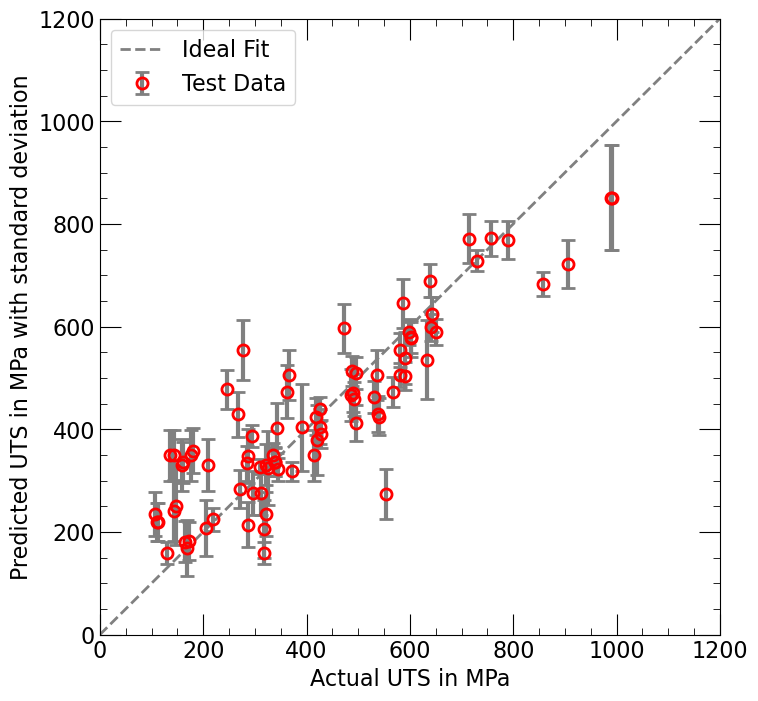

In [22]:
plt.figure(figsize=(8,8))

plt.errorbar(y_test,mean,yerr=std,ecolor = 'grey',mfc='None', mec='red',mew=2,elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Test Data')

plt.xlabel('Actual UTS in MPa',fontsize=16)
plt.ylabel('Predicted UTS in MPa with standard deviation',fontsize=16)
plt.axline((0, 0), (1200, 1200), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)
plt.xlim(0,1200)
plt.ylim(0,1200)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')

print('r2 score test data:',r2_score(y_test,mean))
print('r2 score train data:',r2_score(y_train,mean_train))   
# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

### Plotting the uncertainties for the train data 

## Section 15: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


r2 score test data: 0.769458343295071
r2 score train data: 0.8697599838227008


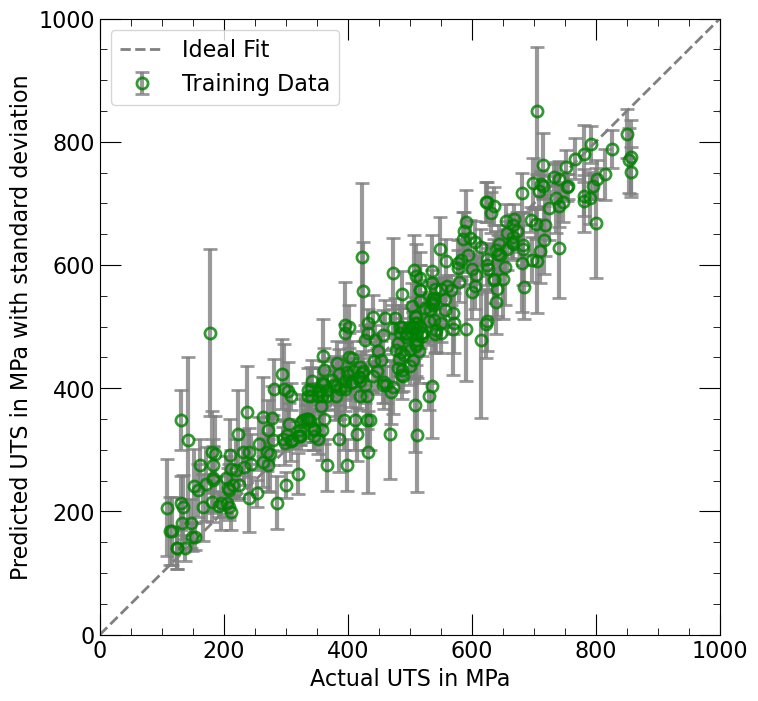

In [23]:
plt.figure(figsize=(8,8))

plt.errorbar(y_train,mean_train,yerr=std_train,mfc='None',mec='green',mew=2,ecolor = 'grey',alpha=0.8, elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Training Data')
plt.xlabel('Actual UTS in MPa',fontsize=16)
plt.ylabel('Predicted UTS in MPa with standard deviation',fontsize=16)
plt.axline((0, 0), (1000, 1000), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


plt.xlim(0,1000)
plt.ylim(0,1000)
print('r2 score test data:',r2_score(y_test,mean))
print('r2 score train data:',r2_score(y_train,mean_train))  

# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

# Generating Virtual Candidates for Our Dataset

## Section 16: Import Libraries

**What we're doing:**
- Import required Python packages:
  - **Data handling**: pandas, numpy
  - **ML models**: scikit-learn, lightgbm
  - **Visualization**: matplotlib, seaborn
  - **Utilities**: scipy, joblib

**Note**: Some imports will be custom modules from cbfv package


In [22]:
from itertools import combinations,product

In [23]:
## FOR ALL 14 elements 
## B, C, N and Si varies from 1 weigth percent to 5 weight percent 
element_ranges ={
    "Al"   : np.arange(1,21,1),
    "Co"   : np.arange(1,21,1),
    "Fe"   : np.arange(1,21,1),
    "Ni"  : np.arange(1,21,1),
    "Si"  : np.arange(1,21,1),
    "Mn"   : np.arange(1,21,1),
    "Cr"  : np.arange(1,21,1),
    "Ti"  : np.arange(1,21,1),
    "Cu"  : np.arange(1,21,1),
    "Mo"  : np.arange(1,21,1),
    "Nb"  : np.arange(1,21,1),
    "V"  : np.arange(1,21,1),
    "Zr"   : np.arange(1,21,1),
    "Sn"  : np.arange(1,21,1),
    "Ta"  : np.arange(1,21,1),
    "Hf"  : np.arange(1,21,1),
    "W"  : np.arange(1,21,1),
    "Zn"   : np.arange(1,21,1),
    "Re"  : np.arange(1,21,1),
    "Mg"  : np.arange(1,21,1),
    "Pd"  : np.arange(1,21,1),
}

elements = ['Co','Fe','Ni','Si','Cr','Mn','Ti','Cu','Mo','Nb','V','Zr','Sn','Ta','Hf','W','Zn','Re','Mg','Pd']

## Section 17: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [24]:
def get_compositions(elements,element_ranges_dict,comb = 3): 
    
    # for quinary alloy compositions comb = 4
    # for quarternary alloy compositions comb = 3
    final_compositions = []
    for elements_sel in combinations(elements,comb):
        element_sel_rangers = [element_ranges_dict[e] for e in elements_sel]
        element_comps = list(product(*element_sel_rangers))
        for element_comp  in element_comps:
            element_comp = np.round(element_comp,1)
            final_prod =  'Al' +str(100 - np.sum(element_comp)) 
            for e,c in zip(elements_sel,element_comp):
              final_prod = final_prod + e +str(c)
            final_compositions.append(final_prod)

            
    return(final_compositions)

## Section 18: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [25]:
%%time
final_composition = get_compositions(elements, element_ranges, comb=3)
len(final_composition)

CPU times: user 31.2 s, sys: 143 ms, total: 31.4 s
Wall time: 31.8 s


9120000

## Section 19: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [26]:
virtual_compositions = pd.DataFrame({"wt_pct":final_composition})

virtual_compositions['T']=25
virtual_compositions['target']=0

## Section 20: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [27]:
virtual_compositions.shape

(9120000, 3)

### Use Virtually Generated Compositions

## Section 21: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [ ]:
%%time
virtual_compositions['formula']=[wtpct_To_atpct(i) for i in virtual_compositions.wt_pct]
virtual_full_compositions = virtual_compositions.copy()
virtual_compositions = virtual_compositions[['formula', 'T', 'target']]

## Section 22: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [29]:
X_comp, y_comp, formulae_comp, skipped_train = generate_features(virtual_compositions,elem_prop='f3_revised',drop_duplicates=False,extend_features=True)

Processing Input Data: 100%|██████████| 9120000/9120000 [04:04<00:00, 37345.20it/s] 


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 9120000/9120000 [03:01<00:00, 50228.85it/s]


	Creating Pandas Objects...


In [30]:
X_comp_avg = X_comp[['avg_Atomic_Radius','avg_Pauling_Electronegativity','avg_number_of_valence_electrons','avg_Cohesive_energy_ev_atom',
            'avg_Bulk_modulus_RT_Gpa','avg_Elastic_modulus_RT_Gpa','avg_Melting_point_(K)','avg_lattice_constant_A','avg_BEC_percm3','avg_Av.Valence_bond_strength_ev','avg_EngelZ_e/a','T']]


In [31]:
X_comp_avg.columns

Index(['avg_Atomic_Radius', 'avg_Pauling_Electronegativity',
       'avg_number_of_valence_electrons', 'avg_Cohesive_energy_ev_atom',
       'avg_Bulk_modulus_RT_Gpa', 'avg_Elastic_modulus_RT_Gpa',
       'avg_Melting_point_(K)', 'avg_lattice_constant_A', 'avg_BEC_percm3',
       'avg_Av.Valence_bond_strength_ev', 'avg_EngelZ_e/a', 'T'],
      dtype='object')

### Normalization and Prediction
### for predicting mean and std deviation of candidate space we have used entire dataset for training keeping the hyperparameters same for the model 

In [32]:
X_train_all = np.concatenate((X_train_unscaled_avg,X_test_unscaled_avg),axis = 0)
y_train_all = np.concatenate((y_train,y_test),axis=0)

scaler = StandardScaler()
X_train_all_scaled = scaler.fit_transform(X_train_all) ## fit and transform training data and 

X_comp_avg_scaled  = scaler.transform(X_comp_avg) # transform test data
print('maximum value of HV in the experimental data:',y_train_all.max())

/Users/rahulbouri/miniconda3/envs/mech/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


maximum value of HV in the experimental data: 1183.0


In [33]:
# Estimating mean and standard deviation for all the available experimental data
mean_train_all , std_train_all  = bootstrap_estimator(gbr_gs_best, X_train_all_scaled, y_train_all, X_train_all_scaled, n_iter=1000)

## Section 23: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


r2 score train data: 0.8653406422086705


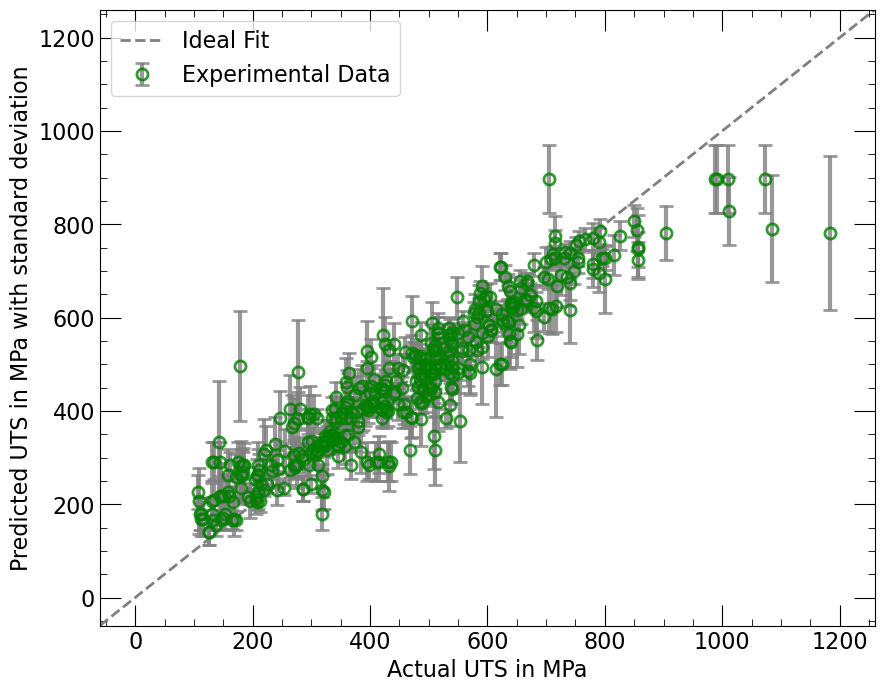

: 

In [ ]:
plt.figure(figsize=(10,8))
plt.errorbar(y_train_all,mean_train_all,yerr=std_train_all,mfc='None',mec='green',mew=2,ecolor = 'grey',alpha=0.8, elinewidth= 3,ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='Experimental Data')
#plt.errorbar(y_train,mean_train,yerr=std_train,ecolor = 'grey', elinewidth= 3,c ='red',ls = 'none',marker='o',markersize=8,solid_capstyle='projecting', capsize=5,label='UTS (MPa) train')

plt.xlabel('Actual UTS in MPa',fontsize=16)
plt.ylabel('Predicted UTS in MPa with standard deviation',fontsize=16)
plt.axline((0, 0), (1200, 1200), linewidth=2, color='grey',linestyle='dashed',label='Ideal Fit')
plt.legend(fontsize=16)

plt.minorticks_on()
plt.tick_params(labelsize=16)
plt.tick_params(direction='in',which='major', length=15, bottom=True, top=True, left=True, right=True,colors='k')
plt.tick_params(direction='in',which='minor', length=5, bottom=True, top=True, left=True, right=True,colors='k')


print('r2 score train data:',r2_score(y_train_all,mean_train_all))   
# mean_squared_error(y_test,mean,squared=False)
# mean_absolute_error(y_test,mean)

### Calculating EI

## Section 24: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


In [ ]:
ei,predicted_property,std = Expected_Improvement(X_comp_avg_scaled, X_train_all_scaled, y_train_all,gbr_gs_best,xi=0.01)

## Section 25: Generate Elemental Descriptors

**What we're doing:**
- Parse alloy formulas to extract element symbols and atomic fractions
- Calculate 14 elemental descriptor statistics:
  - **Atomic properties**: Radius, Electronegativity, Valence electrons
  - **Energetic properties**: Cohesive energy, Bulk/Elastic modulus
  - **Structural properties**: Melting point, Lattice constant, Bond strength
- Normalize features using StandardScaler

**Expected output:**
- Feature matrix: (N_samples, 12) normalized descriptors
- Descriptors ready for model training


In [ ]:
df_predict = pd.DataFrame({"ei":ei, "predicted_property":predicted_property, "std":std})
df_predict_final = virtual_compositions.join(df_predict)
df_predict_final['wt_pct'] = virtual_full_compositions['wt_pct']

df_predict_final_sorted = df_predict_final.sort_values('ei',ascending=False)
df_predict_final_sorted[0:10]

,formula,T,target,ei,predicted_property,std,wt_pct
1,Al98.1Co0.5Fe0.5Ni0.9,25,0,3.542731e-21,569.009844,64.165289,Al96Co1Fe1Ni2
2,Al97.6Co0.5Fe0.5Ni1.4,25,0,3.542731e-21,569.009844,64.165289,Al95Co1Fe1Ni3
3,Al97.1Co0.5Fe0.5Ni1.9,25,0,3.397458e-21,569.121512,64.125338,Al94Co1Fe1Ni4
4,Al96.6Co0.5Fe0.5Ni2.4,25,0,3.355695e-21,569.143768,64.114654,Al93Co1Fe1Ni5
0,Al98.6Co0.5Fe0.5Ni0.5,25,0,3.345698e-21,569.073190,64.119925,Al97Co1Fe1Ni1


## Section 26: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


In [ ]:
df.to_csv('../data/predicted_hardness.csv', index=False)

## Section 27: Model Evaluation

**What we're doing:**
- Generate predictions on test set
- Calculate regression metrics:
  - **R² (R-squared)**: Proportion of variance explained (0-1, higher is better)
  - **MAE (Mean Absolute Error)**: Average |predicted - actual| in HV units
  - **RMSE (Root Mean Squared Error)**: Root of average squared errors
- Create prediction vs actual plots

**Interpretation:**
- R² = 0.77 means 77% of hardness variance is explained by our model
- MAE = 74 HV means predictions are off by ~74 HV on average


In [ ]:
df.to_csv('../data/predicted_hardness_with_ei.csv', index=False)